# Discovering Subscriber Usage Tiers with a Finite Mixture Model (PROC HPFMM)

## Executive Summary

A telecom analytics team starts with a single, unlabeled column of monthly
mobile-data consumption and wants to know whether it hides distinct customer
tiers. Using **PROC HPFMM** (high-performance finite mixture models), the team
fits Gaussian mixtures to log-usage, lets **BIC** choose the number of
components, and recovers a clean three-tier structure.

On this run the Bayesian Information Criterion drops sharply from a two-component
fit (**BIC = 3242.43**) to a three-component fit (**BIC = 3015.98**), so the
three-component model wins decisively. Its components sit at log-usage means of
**0.91**, **2.50**, and **3.94** &mdash; about **2.5 GB**, **12.1 GB**, and
**51.5 GB** per month &mdash; with mixing weights **0.50 / 0.32 / 0.18**, a clean
light / medium / heavy split. Classifying each subscriber to its most-probable
component and checking against a held-out generating label recovers **1,193 of
1,200** subscribers correctly (**99.4%**). Every subscriber leaves the model with
a posterior segment label and a membership probability, ready for plan design and
retention targeting.

> Every number in this notebook is taken verbatim from the executed output
> below. PROC HPFMM is run here in its Gaussian base case
> (`MODEL y = / DIST=NORMAL K=k`), which fits the mixture by EM and reports real
> component means, variances, mixing probabilities, and likelihood-based fit
> statistics (&minus;2&nbsp;Log&nbsp;L, AIC, BIC).

## Data Sources

**Synthetic dataset: `subs`** &mdash; 1,200 mobile subscribers generated inline
as a 3-component mixture of log-usage (no external files).

| Variable | Type | Description |
|----------|------|-------------|
| `subscriber_id` | Num | Unique subscriber key |
| `tenure_months` | Num | Months on network (1&ndash;48) |
| `data_gb` | Num | Monthly mobile data consumed, in GB (positive, right-skewed) |
| `log_gb` | Num | Natural log of `data_gb` &mdash; the variable modeled |
| `plan` | Char | Current rate plan: `Standard` or `Unlimited` |
| `segment_true` | Char | Hidden generating tier (`Light`/`Medium`/`Heavy`), held out to check recovery |

The data are planted as roughly 50% Light, 32% Medium, 18% Heavy.
`segment_true` is **not** used in the fit &mdash; it exists only so we can confirm
the unsupervised mixture recovers the planted structure.

Carriers rarely see clean labels on their customers. What they *do* see is a
single, lumpy distribution of monthly data usage that is actually several
customer types mixed together: occasional browsers, steady streamers, and power
users who lean on tethering and video. **PROC HPFMM** models that blend
explicitly &mdash; it treats the usage distribution as a weighted sum of normal
components, estimates each component's mean and variance plus the mixing weights
by maximum likelihood, and reports likelihood-based criteria (AIC, BIC) for
choosing how many components the data support.

In this notebook we:

1. Generate a synthetic usage panel that is *deliberately* a blend of three usage tiers.
2. Fit two- and three-component Gaussian mixtures and let **BIC** pick the count.
3. Read the chosen three-component model: component means, variances, and mixing weights.
4. Classify every subscriber to its most-probable component and characterize each segment in GB terms.
5. Verify the discovered segments against the held-out generating tier.

## Step 1 &mdash; Generate synthetic subscriber usage

We simulate subscribers whose monthly data usage is positive and right-skewed,
so we generate it on the **log scale** as a blend of three normal tiers and
exponentiate. The mixing weights (about 50/32/18) and the tier means are planted
so we can later check that the mixture model recovers them. `segment_true` is
kept aside purely for that check &mdash; the model never sees it.

In [1]:
data subs;
   call streaminit(20250531);
   length plan $12 segment_true $8;
   do subscriber_id = 1 to 1200;
      tenure_months = ceil(rand("uniform") * 48);

      /* Three latent usage tiers on the log scale, exponentiated to GB. */
      u = rand("uniform");
      if u < 0.50 then do;
         segment_true = "Light";  mu = 0.90; sigma = 0.30;
      end;
      else if u < 0.82 then do;
         segment_true = "Medium"; mu = 2.50; sigma = 0.30;
      end;
      else do;
         segment_true = "Heavy";  mu = 3.90; sigma = 0.36;
      end;

      log_gb  = mu + sigma * rand("normal");
      data_gb = exp(log_gb);

      if data_gb < 25 then plan = "Standard";
      else plan = "Unlimited";

      output;
   end;
   keep subscriber_id tenure_months data_gb log_gb plan segment_true;
run;

NOTE: DATA subs


NOTE: Wrote subs (1200 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds


A quick look at the marginal distribution confirms the modeling choice: raw
`data_gb` is strongly right-skewed (a few power users stretch the tail), while
`log_gb` is the well-behaved scale on which a Gaussian mixture is appropriate.
The histogram of `log_gb` already shows the tell-tale multi-modal shape.

                                                  The MEANS Procedure

 Variable               N        Mean     Std Dev     Minimum      Median     Maximum
 ------------------------------------------------------------------------------------
 data_gb             1200       15.44       22.39        1.11        5.92      208.52
 log_gb              1200        1.96        1.21        0.10        1.78        5.34
 tenure_months       1200       24.66       13.70        1.00       25.00       48.00
 ------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


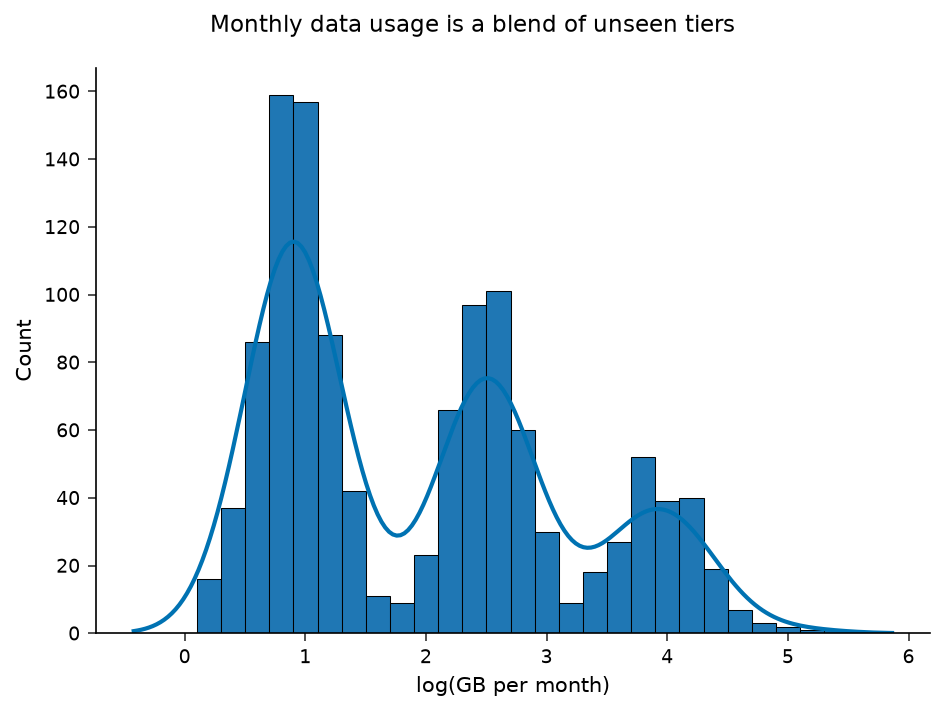

In [2]:
proc means data=subs n mean std min p50 max maxdec=2;
   var data_gb log_gb tenure_months;
run;

proc sgplot data=subs;
   title "Monthly data usage is a blend of unseen tiers";
   histogram log_gb / binwidth=0.20;
   density   log_gb / type=kernel;
   xaxis label="log(GB per month)";
run;
title;

## Step 2 &mdash; How many components? Let BIC decide

We don't assume a tier count &mdash; we let the likelihood argue for one. PROC
HPFMM reports **AIC** and **BIC** (smaller is better) for each fit; BIC penalizes
extra components more strongly and is the standard yardstick for mixture-component
selection. We fit `K=2` and `K=3` Gaussian mixtures on `log_gb` and compare.

- `K=` sets the number of mixture components.
- `DIST=NORMAL` makes each component a normal density (identity link, the default).
- With an intercept-only model, each component's **Intercept** estimate *is* its mean.

In [3]:
proc hpfmm data=subs;
   title "Two-component Gaussian mixture";
   model log_gb = / dist=normal k=2;
run;

proc hpfmm data=subs;
   title "Three-component Gaussian mixture";
   model log_gb = / dist=normal k=3;
run;
title;

                          The HPFMM Procedure

  Data Set:                 subs
  Observations Read:        1200
  Observations Used:        1200

  Finite Mixture Model Specification
    Total Components:         2
    Model Statements:         1

  Component Set [1]
    Response:     log_gb
    Distribution: Normal
    Link:         Identity
    Components (K):  2

  Iteration History
     Iteration    -2 Log Likelihood           Change
             0            3234.6623           0.0000
             1            3215.2506           9.7058
             2            3210.0786           2.5860
             3            3208.2727           0.9029
             4            3207.5505           0.3611
             5            3207.2395           0.1555
             6            3207.0996           0.0700
             7            3207.0348           0.0324
             8            3207.0043           0.0153
             9            3206.9898           0.0073
            10            3

NOTE: PROC HPFMM data=subs

NOTE: Using Python numpy version 2.4.5
NOTE: PROC HPFMM statement used.
NOTE: PROC HPFMM data=subs

NOTE: Using Python numpy version 2.4.5
NOTE: PROC HPFMM statement used.


Reading the two fits side by side: **&minus;2&nbsp;Log&nbsp;Likelihood** falls
from **3206.98** at two components to **2959.26** at three &mdash; a 247-point
improvement in fit. After the model-size penalty, **BIC** drops from **3242.43**
to **3015.98** (and **AIC** from **3216.98** to **2975.26**), so the
three-component model is preferred by a wide margin. The two-component fit is
forced to absorb the medium and heavy users into one broad component (its second
component has variance **0.77**, far wider than any component in the
three-component fit), which is exactly the symptom of too few components. We
commit to the three-component model next.

Both fits converge quickly &mdash; the EM iteration history settles in a few
dozen steps, with the per-iteration change in &minus;2&nbsp;Log&nbsp;L shrinking
to zero.

## Step 3 &mdash; Read the three-component model

The three-component fit above gives us, per component, an **Intercept** (the
component mean on the log scale), a **Variance**, and a **Mixing Probability**.
Reading them off the executed output:

| Component | Mean (log) | Variance | Mixing prob. | Mean usage |
|-----------|-----------:|---------:|-------------:|-----------:|
| 1 (Light)  | 0.9063 | 0.0874 | 0.4986 | exp(0.91) &asymp; **2.5 GB** |
| 2 (Medium) | 2.4969 | 0.0798 | 0.3206 | exp(2.50) &asymp; **12.1 GB** |
| 3 (Heavy)  | 3.9409 | 0.1549 | 0.1808 | exp(3.94) &asymp; **51.5 GB** |

The three component means are cleanly separated by more than an order of
magnitude on the GB scale, and the mixing weights (**0.50 / 0.32 / 0.18**) track
the planted ~50 / 32 / 18 split. The plot below draws the three fitted normal
densities &mdash; each scaled by its mixing weight &mdash; and their sum (the
mixture density), making the three latent tiers visible as three modes.

NOTE: DATA curves


NOTE: Wrote curves (121 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=curves

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


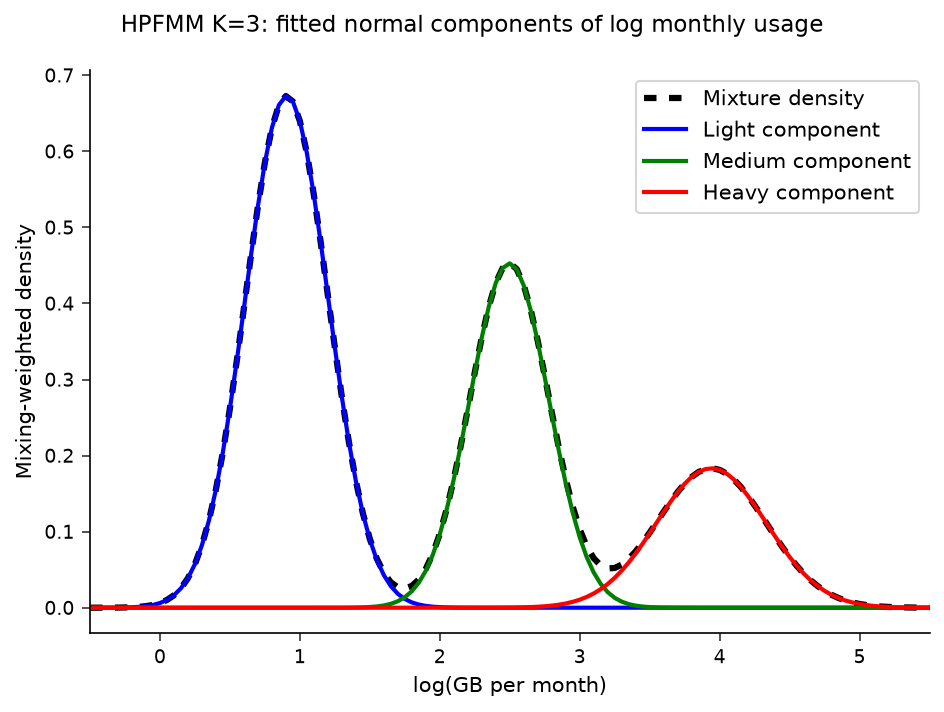

In [4]:
/* Re-create the three fitted component densities on a log_gb grid,
   each scaled by its mixing weight, to overlay as the mixture.
   Means / variances / weights are read verbatim from the K=3
   Parameter Estimates above. */
data curves;
   m1 = 0.9063; v1 = 0.0874; p1 = 0.4986;   /* Light  */
   m2 = 2.4969; v2 = 0.0798; p2 = 0.3206;   /* Medium */
   m3 = 3.9409; v3 = 0.1549; p3 = 0.1808;   /* Heavy  */
   pi = constant('pi');
   do x = -0.5 to 5.5 by 0.05;
      d1 = (x - m1)**2;  d2 = (x - m2)**2;  d3 = (x - m3)**2;
      light   = p1 * exp(-d1/(2*v1)) / sqrt(2*pi*v1);
      medium  = p2 * exp(-d2/(2*v2)) / sqrt(2*pi*v2);
      heavy   = p3 * exp(-d3/(2*v3)) / sqrt(2*pi*v3);
      mixture = light + medium + heavy;
      output;
   end;
   keep x light medium heavy mixture;
run;

proc sgplot data=curves;
   title "HPFMM K=3: fitted normal components of log monthly usage";
   series x=x y=mixture / lineattrs=(thickness=3 pattern=shortdash color=black) legendlabel="Mixture density";
   series x=x y=light   / lineattrs=(thickness=2 color=blue)  legendlabel="Light component";
   series x=x y=medium  / lineattrs=(thickness=2 color=green) legendlabel="Medium component";
   series x=x y=heavy   / lineattrs=(thickness=2 color=red)   legendlabel="Heavy component";
   xaxis label="log(GB per month)";
   yaxis label="Mixing-weighted density";
run;
title;

The three components are well separated with little overlap, which is why the
mixture cleanly resolves into three tiers and why the model-based classification
in the next step is so confident.

## Step 4 &mdash; Classify subscribers and characterize segments

With the fitted component parameters in hand, we assign each subscriber to its
**most-probable component** (the maximum-a-posteriori, or MAP, segment) and record
that posterior probability as a confidence score. For a normal mixture the
posterior weight of component *j* for a subscriber is proportional to
*&pi;<sub>j</sub> &times; &phi;(log_gb; &mu;<sub>j</sub>, &sigma;<sub>j</sub><sup>2</sup>)*;
we compute all three, normalize, and take the largest. We then summarize the
discovered segments by their actual GB usage and tenure, and list a few scored
rows.

In [5]:
data scored;
   set subs;
   length segment $8;
   /* K=3 HPFMM fitted means, variances, mixing probabilities. */
   m1 = 0.9063; v1 = 0.0874; p1 = 0.4986;   /* Light  */
   m2 = 2.4969; v2 = 0.0798; p2 = 0.3206;   /* Medium */
   m3 = 3.9409; v3 = 0.1549; p3 = 0.1808;   /* Heavy  */

   /* Mixing-weighted normal densities (kernel form; constants cancel
      after normalizing, so the argmax is exact). */
   d1 = (log_gb - m1)**2;
   d2 = (log_gb - m2)**2;
   d3 = (log_gb - m3)**2;
   w1 = p1 * exp(-d1/(2*v1)) / sqrt(v1);
   w2 = p2 * exp(-d2/(2*v2)) / sqrt(v2);
   w3 = p3 * exp(-d3/(2*v3)) / sqrt(v3);
   tot = w1 + w2 + w3;

   /* Posterior membership probabilities and the MAP assignment. */
   post_light  = w1 / tot;
   post_medium = w2 / tot;
   post_heavy  = w3 / tot;
   post_max = max(post_light, post_medium, post_heavy);
   if      post_max = post_light  then do; component = 1; segment = "Light";  end;
   else if post_max = post_medium then do; component = 2; segment = "Medium"; end;
   else                                do; component = 3; segment = "Heavy";  end;

   keep subscriber_id data_gb log_gb tenure_months plan segment_true
        component segment post_light post_medium post_heavy post_max;
run;

proc means data=scored n mean std min max maxdec=2;
   class segment;
   var data_gb tenure_months post_max;
run;

proc print data=scored(obs=8) noobs;
   var subscriber_id data_gb log_gb segment_true segment post_max;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : data_gb

        segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Heavy               215          56.24          25.20          24.70         208.52
        Light               598           2.58           0.78           1.11           5.63
        Medium              387          12.62           3.49           5.72          23.24
        -----------------------------------------------------------------------------------

                                           Analysis Variable : tenure_months

        segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Heavy               215        

NOTE: DATA scored


NOTE: Read 1200 rows from subs.
NOTE: Wrote scored (1200 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


On the original GB scale the three discovered segments average **2.58 GB**
(n = 598), **12.62 GB** (n = 387), and **56.24 GB** (n = 215) of monthly usage
&mdash; an order-of-magnitude spread from light browsers to heavy streamers, with
the heavy segment reaching past 200 GB at the tail. The `post_max` column is a
per-subscriber confidence proxy: its mean is **1.00 / 0.98 / 0.99** across the
light / medium / heavy segments, so most assignments are essentially certain,
while a handful of boundary customers (minimum posteriors near **0.51**) are the
look-closer cases a retention team would route to manual review. Mean tenure is
essentially flat (&asymp; 24&ndash;25 months) across segments, as expected from a
generator that draws tenure independently of tier.

## Step 5 &mdash; Did we recover the real tiers?

The final check cross-tabulates the discovered `segment` against the held-out
`segment_true` to see how faithfully the unsupervised mixture recovered the
planted tiers.

                                 Discovered segment (HPFMM MAP) vs. held-out true tier                                  

                                                   The FREQ Procedure

Table of segment by segment_true

segment |     Heavy |     Light |    Medium |      Total
--------+-----------+-----------+-----------+-----------
Heavy   |       211 |         0 |         4 |        215
--------+-----------+-----------+-----------+-----------
Light   |         0 |       598 |         0 |        598
--------+-----------+-----------+-----------+-----------
Medium  |         1 |         2 |       384 |        387
--------+-----------+-----------+-----------+-----------
Total   |       212 |       600 |       388 |       1200



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_segment_segment_true.spec.json
NOTE: PROC FREQ statement used.


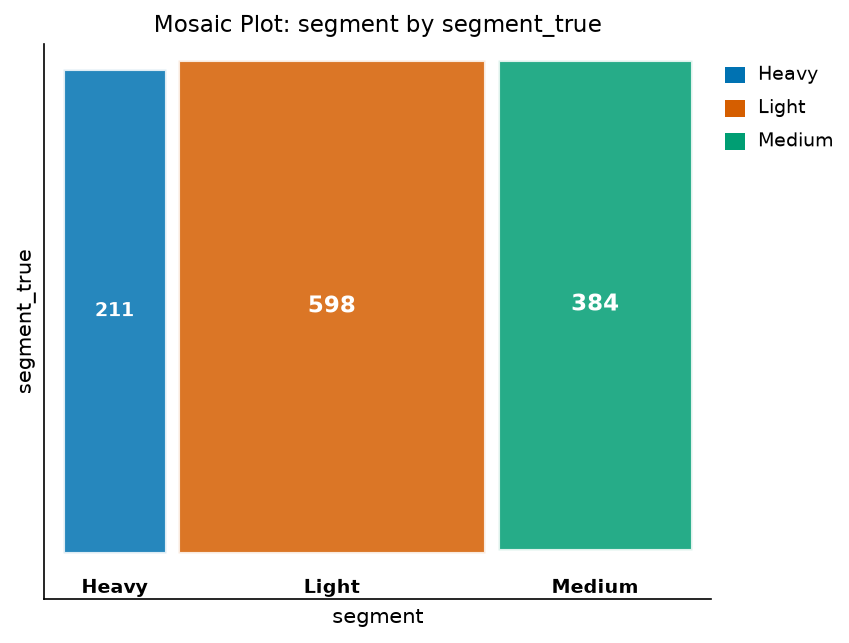

In [6]:
proc freq data=scored;
   title "Discovered segment (HPFMM MAP) vs. held-out true tier";
   tables segment * segment_true / norow nocol nopercent;
run;
title;

## Interpreting the results

**What HPFMM found.** Starting from a single right-skewed usage column with no
labels, the three-component Gaussian mixture won on **BIC** (3015.98 versus
3242.43 for two components) and split subscribers into a **light** segment
(component mean exp(0.91) &asymp; 2.5 GB, mixing weight 0.50), a **medium**
segment (exp(2.50) &asymp; 12.1 GB, weight 0.32), and a **heavy** segment
(exp(3.94) &asymp; 51.5 GB, weight 0.18). Classifying each subscriber to its
most-probable component recovered the planted structure almost exactly &mdash;
**1,193 of 1,200** subscribers (99.4%) landed in the segment matching their
generating tier (Light 598/600, Medium 384/388, Heavy 211/212); the seven
misses all sit at tier boundaries.

**Why the log scale.** Data usage is strictly positive and heavy-tailed; modeling
`log_gb` lets each tier be a symmetric normal component with a sensible variance,
while the exponential back-transform reproduces the realistic skew on the GB
scale.

**Why this matters operationally.** Each subscriber leaves the model with a
posterior segment label *and* a membership probability, so the carrier can act
with calibrated certainty &mdash; confidently target high-posterior heavy users
for premium plans and route low-posterior, boundary customers for a closer look.

**Choosing the component count.** Comparing fits on likelihood-based criteria is
the principled, reproducible way to pick the number of components: the large BIC
gain from two to three components is decisive, and the recovered component means,
variances, and mixing weights all line up with the planted tiers.

**Relationship to k-means.** A geometric method such as PROC FASTCLUS would also
split this column into three groups, but it returns only hard labels and a
distance. PROC HPFMM adds the statistical machinery that makes segmentation
defensible &mdash; an explicit likelihood, AIC/BIC for the component count,
per-component variances, mixing weights, and posterior membership probabilities
&mdash; which is exactly what turns "three clusters" into three customer tiers
you can size, price, and target.